In [28]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from  vip_slap2_analysis.behavior import preprocess as ps
from vip_slap2_analysis.utils.utils import normalize_timeseries as normalize

sns.set()
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%xmode Plain

Exception reporting mode: Plain


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
%matplotlib notebook

In [5]:
basepath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics"

In [6]:
summary_path = glob.glob(os.path.join(basepath,'**summary.xlsx'))[0]
summary_df = pd.read_excel(summary_path,sheet_name='subjects')
session_df = pd.read_excel(summary_path,sheet_name='sessions')

In [7]:
target_mice = [826033]

In [8]:
process_df = session_df[(session_df['subject_id'].isin(target_mice))&(session_df['session_type']!='expression_check')]

In [9]:
process_df

,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_name,instrument_id,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
75,826033_2026-02-17_13-13-55,826033,2,2026-02-17,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,slap2_albert,SLAP2_1,yes,no,VCO.1,good,stimlus ID not recorded properly,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
76,826033_2026-02-18_11-57-04,826033,3,2026-02-18,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,slap2_albert,SLAP2_1,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
77,826033_2026-02-19_13-47-57,826033,4,2026-02-19,iGluSnFR4,RCaMP3,50,200,change_detection_passive,familiar,...,slap2_albert,SLAP2_1,yes,no,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


### Process DoC session collected w/ HARP/Bonsai

In [10]:
for idx,row in process_df.iterrows():
    try:
        harp_path = glob.glob(os.path.join(row['session_dir'],'**','**Behavior.harp'),recursive=True)[0]
        print(harp_path)
        if 'device.yml' in os.listdir(harp_path):
            print('metadata present')
        else:
            print('no metadata')
        if 'extracted_files' in os.listdir(harp_path):
            print('processed')
            pass
        else:
            print('processing...')
            try:
                ps.process_single_harp_session(harp_path)
            except:
                print('error processing')
        print('\n')
    except:
        
        print(f'No path for {row["session"]}','\n')

\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-17_13-13-55\behavior\VCO1_Behavior.harp
metadata present
processed


\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-18_11-57-04\behavior\VCO1_Behavior.harp
metadata present
processed


\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-19_13-47-57\behavior\VCO1_Behavior.harp
metadata present
processed




### QC behavior data

In [15]:
bad_sessions = []

for idx,row in process_df.iterrows():
    datapath = glob.glob(os.path.join(row['session_dir'],'**','**bonsai_event_log.csv'),recursive=True)[0]
    print(f"Checking data for {row['session_dir']}...")
    stim_df = pd.read_csv(datapath)
    num_stim_names = len([n for n in stim_df['Value'].unique() if '.tiff' in n])
    print(f'Number of unique stimulus IDs = {num_stim_names}')
    
    if num_stim_names<=1:
        print('STIMULUS ID NOT CORRECTLY RECORDED\n')
        bad_sessions.append(row['session_id'])
    else:
        print('QC passed')
        print('QC passed, correcting image presentation times to HARP...')
#         frame_df = ps.extract_frame_times(stim_df)
#         print("Last frame timestamp:", frame_df["Timestamp"].iloc[-1])
#         print("Last frame index:", frame_df["Frame"].iloc[-1])
        
#         pd_path = glob.glob(os.path.join(Path(datapath).parents[0],'extracted_files','photodiode.pkl'),recursive=True)[0]
#         photodiode_df = pd.read_pickle(pd_path)
        
#         t, y = ps._harp_time_and_signal(photodiode_df)
#         edges = ps.get_signal_edges(y, t)
#         print("Median HARP rise interval:", np.median(np.diff(edges["t_rise"])))
#         print("Num rises:", len(edges["t_rise"]))
        
#         stimulus_df,_ = ps.align_event_log_to_harp(stim_df,photodiode_df,qc_dir=Path(datapath).parents[1],savepath = datapath)
        stimulus_df = ps.correct_event_log(stim_df,photodiode_df,savepath = datapath)

        try:
            pd_df['time'] = pd_df.index - pd_df.index[0]

            fig,ax=plt.subplots(figsize=(16,10),sharex=True)

            norm_pd = normalize(pd_df['AnalogInput0'])

            ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
            ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

            bon_peaks = find_peaks(stimulus_df['photodiode_state'],distance = 5,height=1)[0]
            ax.plot(stimulus_df['corrected_timestamp_harp'],stimulus_df['photodiode_state'])
            ax.set_ylabel('Photodiode value')
            ax.set_xlabel('BonVision time (s)')
            a = ax.scatter(stimulus_df['corrected_timestamp_harp'][bon_peaks],stimulus_df['photodiode_state'][bon_peaks],color='r')

            harp_peaks = find_peaks(norm_pd,distance = 700,height=0.5)[0]
            ax.plot(pd_df['time'],norm_pd)
            ax.set_ylabel('Photodiode value')
            ax.set_xlabel('HARP time (s)')
            b = ax.scatter(pd_df['time'].iloc[harp_peaks],norm_pd.values[harp_peaks],color='g')

            ax.set_title('Photodiode overlap',fontsize=25)

            ax.legend(handles=[a,b],labels=[f'BonVision pulses, n = {len(bon_peaks)}',f'HARP pulse, n = {len(harp_peaks)}'],frameon=False,fontsize=12)

            fig.tight_layout()
        except:
            print(f'Failed to correct timestamps for {row["session_id"]}')
            pass

Checking data for \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-17_13-13-55...
Number of unique stimulus IDs = 1
STIMULUS ID NOT CORRECTLY RECORDED

Checking data for \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-18_11-57-04...
Number of unique stimulus IDs = 7
QC passed
QC passed, correcting image presentation times to HARP...
Median frame rate of LCD screen: 29.9693 Hz
Time offset of image presentation from photodiode signal: -0.7711 seconds
Saved stimulus table to savepath
Failed to correct timestamps for 826033_2026-02-18_11-57-04
Checking data for \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-19_13-47-57...
Number of unique stimulus IDs = 7
QC passed
QC passed, correcting image presentation times to HARP...
Median frame rate of LCD screen: 29.9693 Hz
Time offset of image presentation from photodiode signal: -0.7711 seconds
Saved stim

In [ ]:
datapath

### Test new alignment method photodiode signal captured in bonsai_event_log.csv

In [ ]:
stim_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\test_subject\test_subject_2026-02-20_13-34-41\behavior\VCO1_Behavior.harp\bonsai_event_log.csv"
pd_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\test_subject\test_subject_2026-02-20_13-34-41\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl"

In [ ]:
stim_df = pd.read_csv(stim_path)
pd_df = pd.read_pickle(pd_path)
pd_df['time'] = pd_df.index - pd_df.index[0]

In [ ]:
stim_df

In [ ]:
val = stim_df['Value'].astype(str)

pd_event = np.full(len(stim_df), np.nan, dtype=float)
pd_event[val.str.fullmatch(r"Photodiode-1", case=False)] = 1.0
pd_event[val.str.fullmatch(r"Photodiode-0", case=False)] = 0.0

stim_df["photodiode_event"] = pd_event
stim_df["photodiode_state"] = pd.Series(pd_event).ffill().to_numpy()

In [ ]:
stim_df

In [ ]:
# stimulus_df = ps.align_event_log_to_harp(stim_df,pd_df,qc_dir=Path(stim_path).parents[1],savepath = stim_path)

In [ ]:
fig,ax=plt.subplots(2,figsize=(16,10),sharex=True)

for axis in ax.flatten():
    axis.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
    axis.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

bon_peaks = find_peaks(stim_df['photodiode_state'],distance = 5,height=1)[0]
ax[0].plot(stim_df['Timestamp'],stim_df['photodiode_state'])
ax[0].set_ylabel('Photodiode value')
ax[0].set_xlabel('BonVision time (s)')
a = ax[0].scatter(stim_df['Timestamp'][peaks],stim_df['photodiode_state'][peaks],color='r')
ax[0].set_title('BonVision photodiode signal',fontsize=25)
ax[0].legend(handles=[a],labels=[f'Photodiode pulse, n = {len(bon_peaks)}'],frameon=False,fontsize=12)

harp_peaks = find_peaks(pd_df['AnalogInput0'],distance = 600,height=100)[0]
ax[1].plot(pd_df['time'],pd_df['AnalogInput0'])
ax[1].set_ylabel('Photodiode value')
ax[1].set_xlabel('HARP time (s)')
ax[1].scatter(pd_df['time'].iloc[harp_peaks],pd_df['AnalogInput0'].iloc[harp_peaks],color='r')
ax[1].set_title('HARP photodiode signal',fontsize=25)
ax[1].legend(handles=[a],labels=[f'Photodiode pulse, n = {len(harp_peaks)}'],frameon=False,fontsize=12)

fig.tight_layout()

In [16]:
data_dir = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\temp"

In [ ]:
harp_paths = glob.glob(os.path.join(data_dir,'**','**.harp'),recursive=True)

In [ ]:
for path in harp_paths:
    ps.process_single_harp_session(path)

In [ ]:
Path(stim_path).parents[2].stem

In [ ]:
for i,path in enumerate(harp_paths):
    stim_path = glob.glob(os.path.join(path,'*.csv'))[0]
    pd_path = glob.glob(os.path.join(path,'**','photodiode.pkl'))[0]
    
    stim_df = pd.read_csv(stim_path)
    pd_df = pd.read_pickle(pd_path)
    
    pd_df['time'] = pd_df.index - pd_df.index[0]
    
    val = stim_df['Value'].astype(str)
    pd_event = np.full(len(stim_df), np.nan, dtype=float)
    pd_event[val.str.fullmatch(r"Photodiode-1", case=False)] = 1.0
    pd_event[val.str.fullmatch(r"Photodiode-0", case=False)] = 0.0

    stim_df["photodiode_event"] = pd_event
    stim_df["photodiode_state"] = pd.Series(pd_event).ffill().to_numpy()

    fig,ax=plt.subplots(2,figsize=(16,10),sharex=True)

    for axis in ax.flatten():
        axis.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
        axis.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

    bon_peaks = find_peaks(stim_df['photodiode_state'],distance = 5,height=1)[0]
    ax[0].plot(stim_df['Timestamp']+.110,stim_df['photodiode_state'])
    ax[0].set_ylabel('Photodiode value')
    ax[0].set_xlabel('BonVision time (s)')
    a = ax[0].scatter(stim_df['Timestamp'][bon_peaks],stim_df['photodiode_state'][bon_peaks],color='r')
    ax[0].set_title('BonVision photodiode signal',fontsize=25)
    ax[0].legend(handles=[a],labels=[f'Photodiode pulse, n = {len(bon_peaks)}'],frameon=False,fontsize=12)

    harp_peaks = find_peaks(pd_df['AnalogInput0'],distance = 700,height=100)[0]
    ax[1].plot(pd_df['time'],pd_df['AnalogInput0'])
    ax[1].set_ylabel('Photodiode value')
    ax[1].set_xlabel('HARP time (s)')
    ax[1].scatter(pd_df['time'].iloc[harp_peaks],pd_df['AnalogInput0'].iloc[harp_peaks],color='r')
    ax[1].set_title('HARP photodiode signal',fontsize=25)
    ax[1].legend(handles=[a],labels=[f'Photodiode pulse, n = {len(harp_peaks)}'],frameon=False,fontsize=12)

    fig.tight_layout()

    stimulus_df = ps.align_event_log_to_harp(stim_df,pd_df,savepath = stim_path)
    print(f'Corrected time offsets for {Path(stim_path).parents[2].stem}')

In [ ]:
for i,path in enumerate(harp_paths):
    stim_path = glob.glob(os.path.join(path,'*.csv'))[0]
    pd_path = glob.glob(os.path.join(path,'**','photodiode.pkl'))[0]
    
    stim_df = pd.read_csv(stim_path)
    pd_df = pd.read_pickle(pd_path)
    
    pd_df['time'] = pd_df.index - pd_df.index[0]
    
    stimulus_df,_ = ps.align_event_log_to_harp(stim_df,pd_df,savepath = stim_path)
    print(f'Corrected time offsets for {Path(stim_path).parents[2].stem} \nat{stim_path}')

    fig,ax=plt.subplots(figsize=(16,10),sharex=True)

    norm_pd = normalize(pd_df['AnalogInput0'])
    
    ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
    ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

    bon_peaks = find_peaks(stimulus_df['photodiode_state'],distance = 5,height=1)[0]
    ax.plot(stimulus_df['corrected_timestamp_harp'],stimulus_df['photodiode_state'])
    ax.set_ylabel('Photodiode value')
    ax.set_xlabel('BonVision time (s)')
    a = ax.scatter(stimulus_df['corrected_timestamp_harp'][bon_peaks],stimulus_df['photodiode_state'][bon_peaks],color='r')

    harp_peaks = find_peaks(norm_pd,distance = 700,height=0.5)[0]
    ax.plot(pd_df['time'],norm_pd)
    ax.set_ylabel('Photodiode value')
    ax.set_xlabel('HARP time (s)')
    b = ax.scatter(pd_df['time'].iloc[harp_peaks],norm_pd.values[harp_peaks],color='g')
    
    ax.set_title('Photodiode overlap',fontsize=25)
    
    ax.legend(handles=[a,b],labels=[f'BonVision pulses, n = {len(bon_peaks)}',f'HARP pulse, n = {len(harp_peaks)}'],frameon=False,fontsize=12)

    fig.tight_layout()

In [ ]:
fig,ax=plt.subplots()

ax.plot(pd_df['time'],pd_df['AnalogInput0'])

In [ ]:
pd_df['time'] = pd_df.index - pd_df.index[0]

In [ ]:
pd_df = pd.read_pickle(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-18_11-57-04\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl")

In [ ]:
norm_pd.values

In [35]:
data_dir = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\temp"

In [36]:
stim_paths = glob.glob(os.path.join(data_dir,'**.csv'))
pd_paths = glob.glob(os.path.join(data_dir,'**.pkl'))

<IPython.core.display.Javascript object>


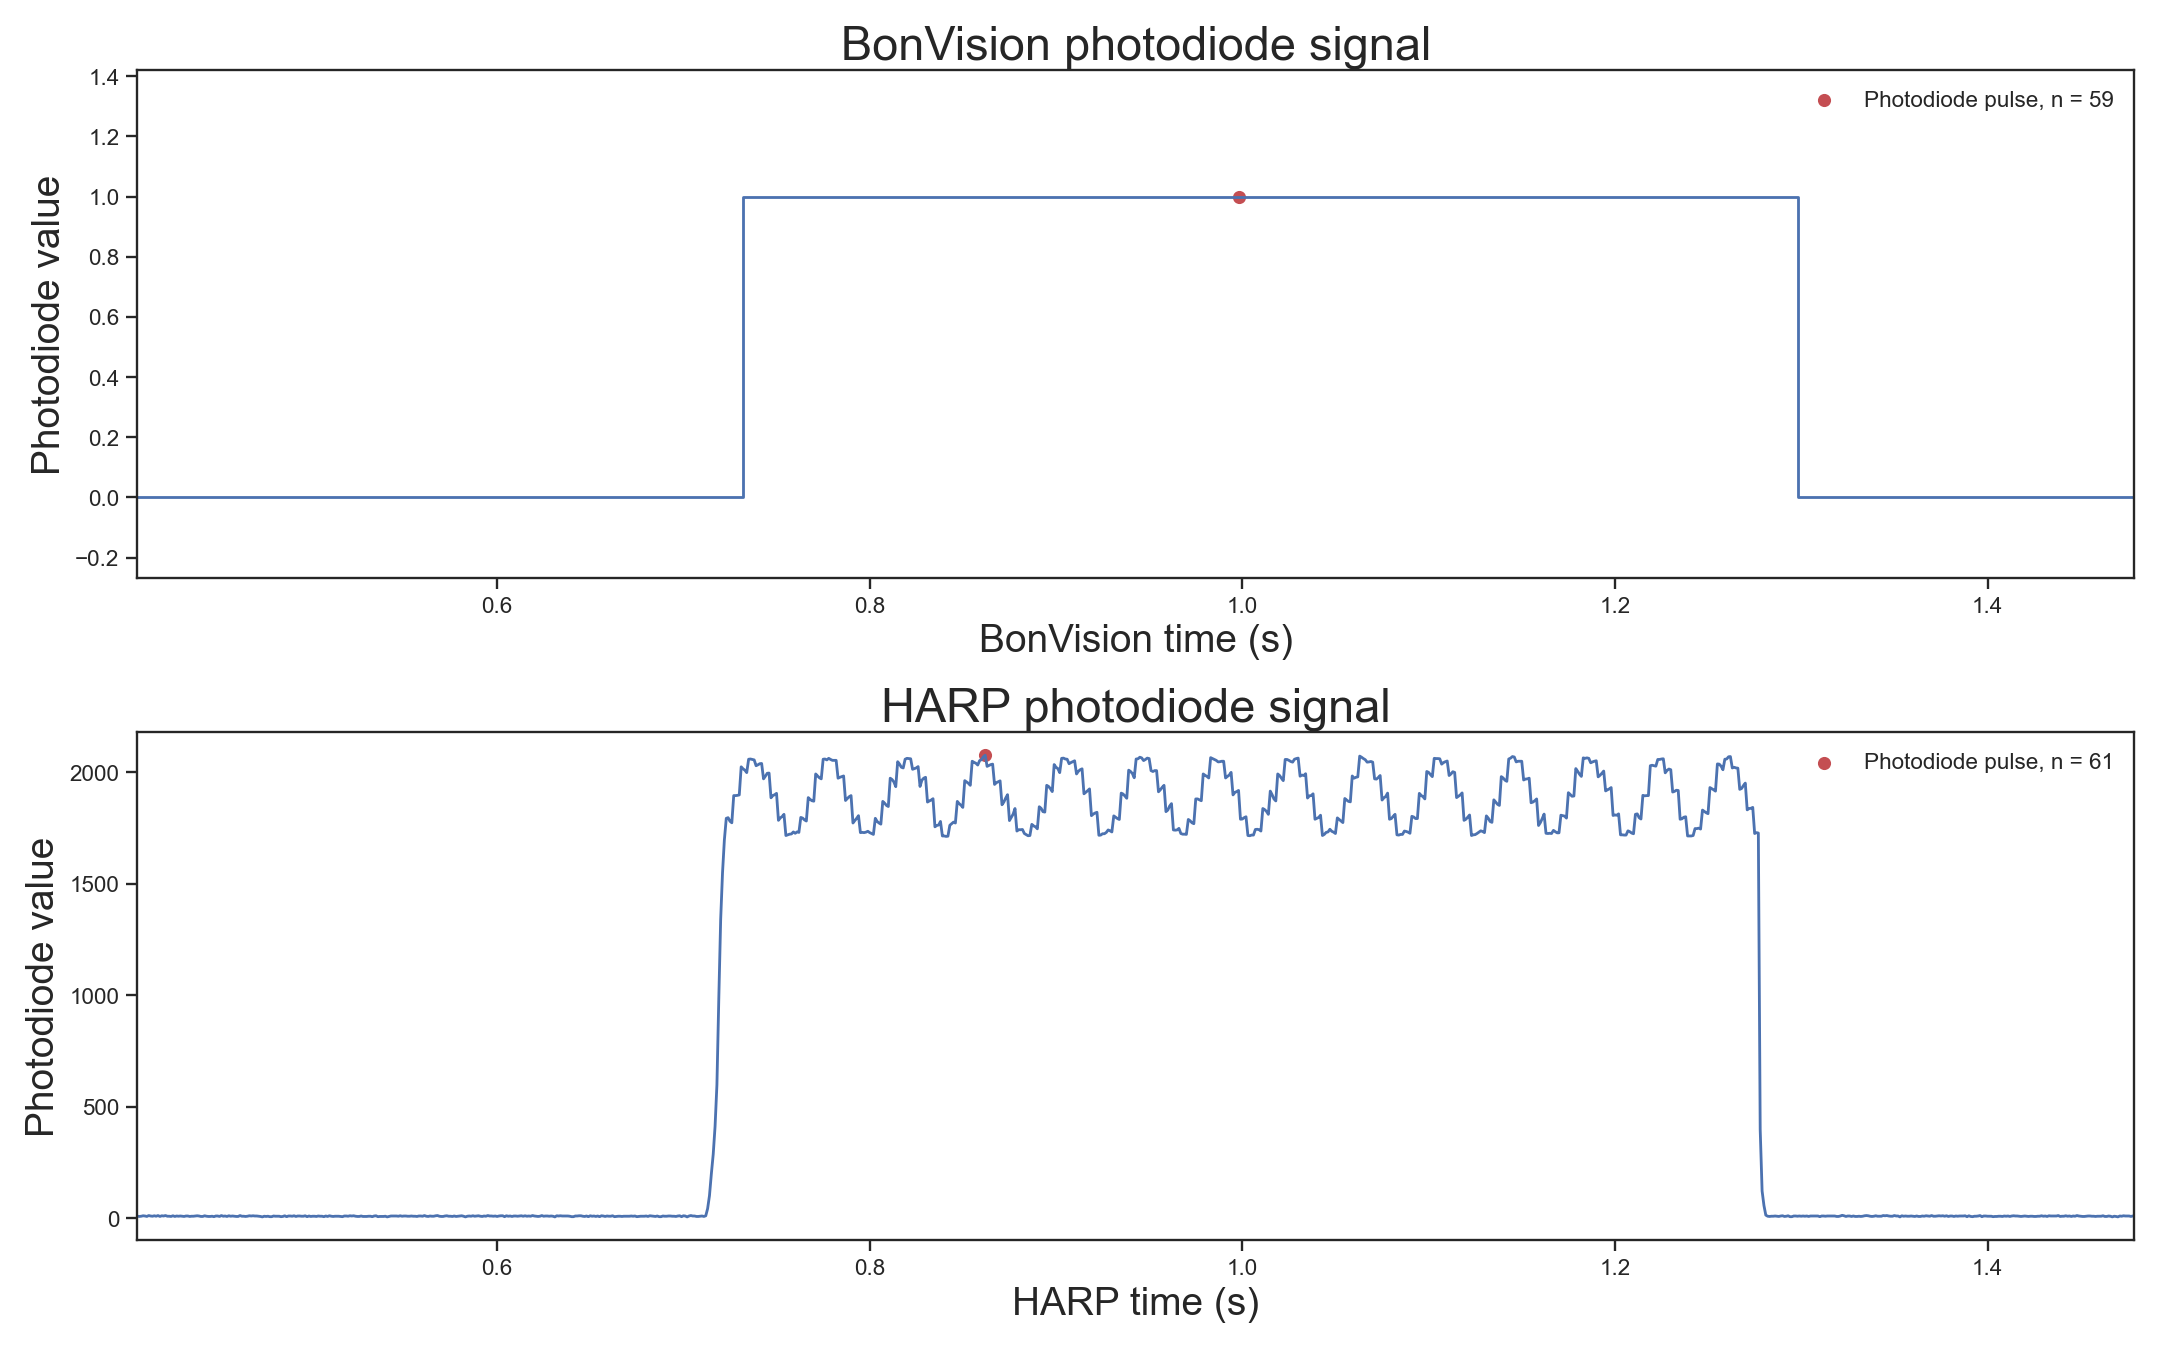

In [39]:
for i,(s_path,p_path) in enumerate(zip(stim_paths,pd_paths)):
    stim_df,meta = ps.correct_event_log(s_path,p_path,savepath=s_path)
    
    if i==1:
        pd_df = pd.read_pickle(p_path)
        pd_df['time'] = pd_df.index - pd_df.index[0]
        
        fig,ax=plt.subplots(2,figsize=(16,10),sharex=True)

        for axis in ax.flatten():
            axis.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
            axis.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

        bon_peaks = find_peaks(stim_df['photodiode_state'],distance = 5,height=1)[0]
        ax[0].plot(stim_df['corrected_timestamps'],stim_df['photodiode_state'])
        ax[0].set_ylabel('Photodiode value')
        ax[0].set_xlabel('BonVision time (s)')
        a = ax[0].scatter(stim_df['corrected_timestamps'][bon_peaks],stim_df['photodiode_state'][bon_peaks],color='r')
        ax[0].set_title('BonVision photodiode signal',fontsize=25)
        ax[0].legend(handles=[a],labels=[f'Photodiode pulse, n = {len(bon_peaks)}'],frameon=False,fontsize=12)

        harp_peaks = find_peaks(pd_df['AnalogInput0'],distance = 600,height=100)[0]
        ax[1].plot(pd_df['time'],pd_df['AnalogInput0'])
        ax[1].set_ylabel('Photodiode value')
        ax[1].set_xlabel('HARP time (s)')
        b = ax[1].scatter(pd_df['time'].iloc[harp_peaks],pd_df['AnalogInput0'].iloc[harp_peaks],color='r')
        ax[1].set_title('HARP photodiode signal',fontsize=25)
        ax[1].legend(handles=[b],labels=[f'Photodiode pulse, n = {len(harp_peaks)}'],frameon=False,fontsize=12)

        fig.tight_layout()

In [32]:
stim_df

,Frame,Timestamp,Value
0,0,0.033334,Frame
1,0,0.033334,Photodiode-1
2,1,0.077278,Frame
3,1,0.077278,Photodiode-0
4,2,0.110611,Frame
...,...,...,...
3910,1944,64.844289,Frame
3911,1945,64.877623,Frame
3912,1946,64.910956,Frame
3913,1947,64.944289,Frame


In [25]:
pd_df = pd.read_pickle(pd_paths[1])
pd_df['time'] = pd_df.index - pd_df.index[0]